**Decision Tree**

Decision trees are decision making algorithms. They take categorical(discrete value) input features and make decision trees out of those features. Based on the features, the input data is passed through and at each node, the value of the feature determines the route the prediction takes. The final decision is the leaf node the process takes

Decision trees need a few different specifications:
- How do we choose which feature at each node to split on -> try to maximize purity based on entropy
- When do we stup splitting
    - max purity is reached
    - When the tree exceeds a max depth
    - when the improvements stagnate or deteriorate
    - when the number of examples in a node is lower than a threshold

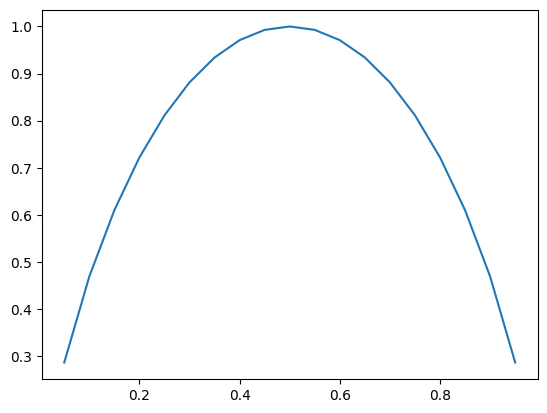

In [5]:
# entropy is a measure of purity. It is high at the middle when there is high probablity of both classes, and low on sides where there is only 1 class predominantly represented

import numpy as np
import matplotlib.pyplot as plt

def H(x_s):
    # entropy curve function for Binary Classification
    return -x_s*np.log2(x_s) - (1-x_s)*np.log2(1-x_s)

x_s = np.arange(0.05,1,0.05)
y_s = H(x_s)

plt.plot(x_s, y_s)


In [8]:
X_train = np.array([[0,1,0,1],[1,0,1,1], [1,1,1,1], [0,0,0,0]])
y_train = np.array([0,1,1,0])

def Inf_gain(X, Y, prev_H):
    feature = 0
    tmp_inf = 0

    for i in range(len(X[0])):
        w_left_0 = 0
        w_right_1 = 0
        p_1_left = 0
        p_1_right = 0
        for j in range(len(X)):
            if X[j][i] == 0:
                w_left_0 += 1
                if Y[j] == 1:
                    p_1_left += 1
            else:
                w_right_1 += 1
                if Y[j] == 1:
                    p_1_right += 1

        w_left_0 *= 1/(len(X[0]))
        w_right_1 *= 1/(len(X[0]))
        p_1_left *= 1/(len(Y))
        p_1_right *= 1/(len(Y))

        inf_gain = prev_H - (w_left_0*H(p_1_left) + w_right_1*H(p_1_right))
        if inf_gain > tmp_inf:
            tmp_inf = inf_gain
            feature = i
    return feature, tmp_inf

print(Inf_gain(X_train, y_train, 1))

(1, np.float64(0.18872187554086717))


C:\Users\kadhi\AppData\Local\Temp\ipykernel_36036\2609066891.py:8: RuntimeWarning: divide by zero encountered in log2
  return -x_s*np.log2(x_s) - (1-x_s)*np.log2(1-x_s)
C:\Users\kadhi\AppData\Local\Temp\ipykernel_36036\2609066891.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  return -x_s*np.log2(x_s) - (1-x_s)*np.log2(1-x_s)


In [ ]:

def split_indices(X, feature):
    left = []
    right = []
    for i,x in enumerate(X):
        if x[feature] == 1:
            left.append(i)
        else:
            right.append(i)
    return left, right



class DecisionNode():
    def __init__(self, population, feature, inf_gain, parent):
        self.population = population # list of indexes of the training set
        self.feature = feature # index value of the feature split on
        self.inf_gain = inf_gain # information gain at this node to compare to
        self.parent = parent # parent node
        self.children = DecisionNode()

def createTree(X_train, y_train):
    feature, inf_gain = Inf_gain(X_train, y_train, 1)
    population = []
    DecisionNode()